In [25]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [26]:
k = 0.1
A0 = 1


def first_order(t, y):
    return -k * y


num_sol = scipy.integrate.solve_ivp(
    first_order, (0, 100), [A0], t_eval=np.linspace(0, 100, 1000)
)

In [27]:
def exact_solution(t):
    return np.exp(-k * t)

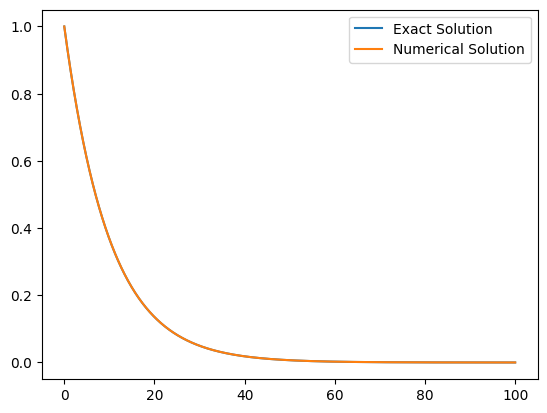

In [28]:
t = np.linspace(0, 100, 1000)

plt.plot(t, exact_solution(t), label="Exact Solution")

plt.plot(t, num_sol.y[0], label="Numerical Solution")

plt.legend()

In [36]:
def first_order_gillespie(initial_copies, k, t_max, volume):
    """
    Simulate a first-order reaction A -> B
    initial copies: list of initial copy numbers [A0, B0]; we want to track A
    """

    t = 0 # Start time
    copies = initial_copies # Initial number of copies
    cv = [k, 0] # rate constants for A -> B and B -> A (if reversible)

    ts = [t] # list to store time points
    copies_over_time = [copies.copy()] # list to store copy numbers over time

    while t < t_max:
        hv = copies
        av = np.multiply(hv, cv) # binding propensity
        a0 = np.sum(av)
        random_n = np.random.uniform(0, 1)
        tau =  -1/(a0 * np.log(random_n))
        t = t + tau

        ts.append(t)
        
        # select a random reaction
        run_sum = av[0]
        v = 1
        while run_sum < random_n * a0:
            run_sum = run_sum + av[v]
            v = v + 1  
        
        ## update species
        if v == 1: # A -> B
            copies[0] = copies[0] - 1
            copies[1] = copies[1] + 1
        copies_over_time.append(copies.copy())

    return ts, copies_over_time


In [64]:
ts, copies_over_time = first_order_gillespie([100, 0], k, 100, 1)

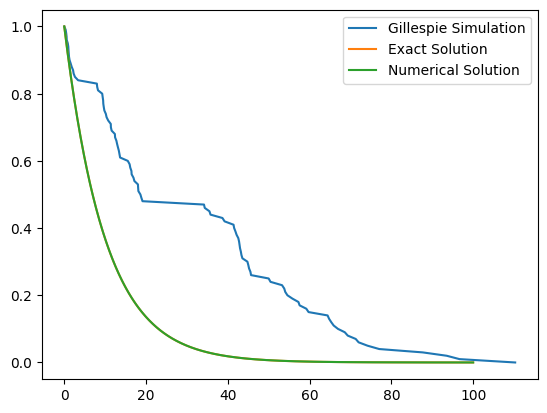

In [65]:
plt.plot(ts, np.array([c[0] for c in copies_over_time])/100, label="Gillespie Simulation")
t = np.linspace(0, 100, 1000)

plt.plot(t, exact_solution(t), label="Exact Solution")

plt.plot(t, num_sol.y[0], label="Numerical Solution")

plt.legend()